# Analisis de Sentimientos


In [3]:
!pip install textblob


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


### Implementacion Simple

In [ ]:
from textblob import TextBlob

# Lista de textos para analizar
textos = [
    "Me encanta este producto, funciona genial",
    "No me ha gustado nada, es terrible",
    "El paquete llegó ayer por la tarde"
]

for texto in textos:
    blob = TextBlob(texto)

    polaridad = blob.sentiment.polarity
    subjetividad = blob.sentiment.subjectivity

    # Clasificación simple según la polaridad
    if polaridad > 0:
        sentimiento = "Positivo"
    elif polaridad < 0:
        sentimiento = "Negativo"
    else:
        sentimiento = "Neutro"

    print("Texto:", texto)
    print("Polaridad:", polaridad)
    print("Subjetividad:", subjetividad)
    print("Sentimiento:", sentimiento)
    print("-" * 40)

Texto: Me encanta este producto, funciona genial
Polaridad: 0.0
Subjetividad: 0.0
Sentimiento: Neutro
----------------------------------------
Texto: No me ha gustado nada, es terrible
Polaridad: -1.0
Subjetividad: 1.0
Sentimiento: Negativo
----------------------------------------
Texto: El paquete llegó ayer por la tarde
Polaridad: 0.0
Subjetividad: 0.0
Sentimiento: Neutro
----------------------------------------


### Implementacion compleja


===== RESULTADOS =====

                                                                        Texto  Polaridad  Subjetividad Sentimiento
This phone is amazing, the battery lasts all day and the camera is fantastic.      0.500         0.900    Positive
                 Customer service was terrible, they took forever to respond.     -1.000         1.000    Negative
                  The restaurant has good food but the service is quite slow.      0.200         0.500    Positive
                                         I have class at nine in the morning.      0.000         0.000     Neutral
            The movie was spectacular, one of the best I have seen this year.      0.800         0.600    Positive
                    I do not recommend this product, it broke after two days.      0.000         0.000     Neutral
          The hotel was clean and well located although the rooms were small.      0.058         0.550     Neutral
                The package arrived yesterday afternoon

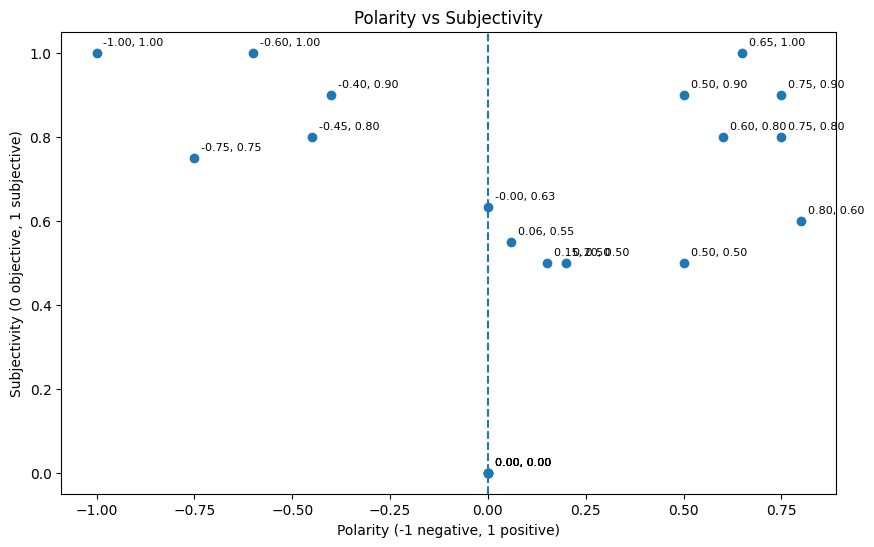

In [7]:
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.3f}'.format



# 1. FUNCIÓN PARA ANALIZAR SENTIMIENTO

def analizar_sentimiento(texto):

    blob = TextBlob(texto)

    polaridad = blob.sentiment.polarity
    subjetividad = blob.sentiment.subjectivity

    if polaridad > 0.1:
        etiqueta = "Positive"
    elif polaridad < -0.1:
        etiqueta = "Negative"
    else:
        etiqueta = "Neutral"

    return polaridad, subjetividad, etiqueta


# 2. TEXTOS EN INGLÉS (para que TextBlob funcione)

textos = [
    "This phone is amazing, the battery lasts all day and the camera is fantastic.",
    "Customer service was terrible, they took forever to respond.",
    "The restaurant has good food but the service is quite slow.",
    "I have class at nine in the morning.",
    "The movie was spectacular, one of the best I have seen this year.",
    "I do not recommend this product, it broke after two days.",
    "The hotel was clean and well located although the rooms were small.",
    "The package arrived yesterday afternoon without any problems.",
    "I am very satisfied with the purchase, it exceeded my expectations.",
    "The app works but sometimes it crashes and becomes frustrating.",
    "The concert was incredible, the energy of the crowd was amazing.",
    "The food was cold and the waiter seemed uninterested.",
    "The exam was difficult but it could have been worse.",
    "The city has many interesting places to visit.",
    "I love this restaurant, I always leave very happy.",
    "The experience was not bad but not particularly good.",
    "The computer runs fast and the screen quality is excellent.",
    "I am quite disappointed with the service quality.",
    "The book is interesting although some parts are heavy.",
    "The meeting ended at five in the afternoon."
]


# 3. ANALIZAR TEXTOS

resultados = []

for texto in textos:

    polaridad, subjetividad, etiqueta = analizar_sentimiento(texto)

    resultados.append({
        "Texto": texto,
        "Polaridad": polaridad,
        "Subjetividad": subjetividad,
        "Sentimiento": etiqueta
    })


df = pd.DataFrame(resultados)



# 4. MOSTRAR RESULTADOS

print("\n===== RESULTADOS =====\n")
print(df.to_string(index=False))


# 5. GRÁFICO DE DISPERSIÓN

plt.figure(figsize=(10,6))

plt.scatter(df["Polaridad"], df["Subjetividad"])

for index, fila in df.iterrows():

    etiqueta = f"{fila['Polaridad']:.2f}, {fila['Subjetividad']:.2f}"

    plt.annotate(
        etiqueta,
        (fila["Polaridad"], fila["Subjetividad"]),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=8
    )

plt.axvline(0, linestyle="--")
plt.title("Polarity vs Subjectivity")
plt.xlabel("Polarity (-1 negative, 1 positive)")
plt.ylabel("Subjectivity (0 objective, 1 subjective)")

plt.show()

### Ejercicios del tema


# Ejercicio 2 — Análisis de reseñas de un restaurante

## Contexto

Muchos restaurantes analizan automáticamente los comentarios de sus clientes en plataformas como Google Reviews o TripAdvisor para entender la satisfacción de los usuarios.

En este ejercicio vamos a analizar el **sentimiento de diferentes reseñas** utilizando la librería `TextBlob`.

---

## Objetivo

A partir de una lista de comentarios:

1. Analizar el **sentimiento de cada comentario**
2. Guardar los resultados en un **DataFrame**
3. Calcular estadísticas básicas
4. Encontrar el comentario **más positivo** y el **más negativo**

---

## Datos

Los comentarios que analizaremos son los siguientes:

- "The food was delicious and the staff was friendly"
- "The service was slow and the food was cold"
- "I had a wonderful experience here"
- "The place is nice but the food is average"
- "Absolutely fantastic restaurant"
- "The waiter was rude"
- "The atmosphere is great"
- "The food was disappointing"
- "I enjoyed the meal"
- "It was okay, nothing special"

---

## Tareas

Implementa un programa que:

1. Analice cada comentario con `TextBlob`
2. Calcule:
   - polaridad
   - subjetividad
3. Clasifique cada comentario como:
   - Positive
   - Negative
   - Neutral
4. Cree un **DataFrame con los resultados**
5. Calcule:
   - media de polaridad
   - número de comentarios por tipo de sentimiento
6. Encuentre:
   - el comentario **más positivo**
   - el comentario **más negativo**

# Ejercicio 3 — Análisis de sentimiento en redes sociales

## Contexto

Las empresas analizan los comentarios de redes sociales para entender la opinión pública sobre sus productos o servicios.

En este ejercicio simularemos el análisis de comentarios sobre una marca.

---

## Objetivo

A partir de una lista de comentarios:

1. Analizar el sentimiento de cada comentario
2. Guardar los resultados en un DataFrame
3. Crear visualizaciones de los resultados

---

## Comentarios a analizar

- "I love this brand!"
- "This update ruined the app"
- "The new design is beautiful"
- "I hate the new interface"
- "The product quality is excellent"
- "The service is awful"
- "The app works perfectly"
- "This is the worst update ever"
- "I really enjoy using this"
- "It is fine but could be better"

---

## Tareas

1. Analizar el sentimiento de cada comentario
2. Crear un DataFrame con los resultados
3. Crear un **gráfico de barras** con el número de comentarios positivos, negativos y neutros
4. Crear un **gráfico de dispersión** con:

- polaridad
- subjetividad

5. Mostrar los valores de polaridad y subjetividad junto a cada punto